## Pipeline for all hgmm datasets with CellBender

In [ ]:
# please specify which dataset you want to process:
# available options: hgmm1k, hgmm5k, hgmm6k, hgmm10k, hgmm12k, hgmm20k
dataset = "hgmm1k"

# please specify path for reading input files
PATH = "hgmm1k"

# please specifiy a raw file_name for CellBender, options are:

# hgmm1k:  SC3_v3_NextGem_DI_Human_Mouse_1K_raw_feature_bc_matrix.h5
# hgmm5k:  hgmm_5k_v3_raw_feature_bc_matrix.h5
# hgmm6k:  5k_hgmm_v3_nextgem_raw_feature_bc_matrix.h5
# hgmm10k: 10k_hgmm_3p_gemx_Multiplex_count_raw_feature_bc_matrix.h5
# hgmm12k: 10k_hgmm_v3_nextgem_raw_feature_bc_matrix.h5
# hgmm20k: 20k_hgmm_3p_HT_nextgem_Chromium_X_raw_feature_bc_matrix.h5 
file_name = "SC3_v3_NextGem_DI_Human_Mouse_1K_raw_feature_bc_matrix.h5"

In [ ]:
import subprocess
import os

dataset_dir = os.path.join(dataset.lower())
os.makedirs(dataset_dir, exist_ok=True)

def download_if_needed(url, target_dir):
    filename = url.split("/")[-1]

    output_path = os.path.join(target_dir, filename)

    if os.path.exists(output_path):
        print(f"File already exists – trying to resume: {filename}")
        subprocess.run(["curl", "-L", "-C", "-", "-o", output_path, url], check=True)
    else:
        print(f"Download file: {filename}")
        subprocess.run(["curl", "-L", "-o", output_path, url], check=True)


if dataset == "hgmm1k":
    urls = [
        "https://cf.10xgenomics.com/samples/cell-exp/4.0.0/SC3_v3_NextGem_DI_Human_Mouse_1K/SC3_v3_NextGem_DI_Human_Mouse_1K_filtered_feature_bc_matrix.h5",
        "https://cf.10xgenomics.com/samples/cell-exp/4.0.0/SC3_v3_NextGem_DI_Human_Mouse_1K/SC3_v3_NextGem_DI_Human_Mouse_1K_raw_feature_bc_matrix.h5"
    ]

elif dataset == "hgmm5k":
    urls = [
        "https://cf.10xgenomics.com/samples/cell-exp/3.0.0/hgmm_5k_v3/hgmm_5k_v3_filtered_feature_bc_matrix.h5",
        "https://cf.10xgenomics.com/samples/cell-exp/3.0.0/hgmm_5k_v3/hgmm_5k_v3_raw_feature_bc_matrix.h5"
    ]

elif dataset == "hgmm6k":
    urls = [
        "https://cf.10xgenomics.com/samples/cell-exp/3.0.2/5k_hgmm_v3_nextgem/5k_hgmm_v3_nextgem_filtered_feature_bc_matrix.h5",
        "https://cf.10xgenomics.com/samples/cell-exp/3.0.2/5k_hgmm_v3_nextgem/5k_hgmm_v3_nextgem_raw_feature_bc_matrix.h5"
    ]

elif dataset == "hgmm10k":
    urls = [
        "https://cf.10xgenomics.com/samples/cell-exp/8.0.0/10k_hgmm_3p_gemx_10k_hgmm_3p_gemx/10k_hgmm_3p_gemx_10k_hgmm_3p_gemx_count_sample_filtered_feature_bc_matrix.h5",
        "https://cf.10xgenomics.com/samples/cell-exp/8.0.0/10k_hgmm_3p_gemx_Multiplex/10k_hgmm_3p_gemx_Multiplex_count_raw_feature_bc_matrix.h5"
    ]

elif dataset == "hgmm12k":
    urls = [
        "https://cf.10xgenomics.com/samples/cell-exp/3.0.2/10k_hgmm_v3_nextgem/10k_hgmm_v3_nextgem_filtered_feature_bc_matrix.h5",
        "https://cf.10xgenomics.com/samples/cell-exp/3.0.2/10k_hgmm_v3_nextgem/10k_hgmm_v3_nextgem_raw_feature_bc_matrix.h5"
    ]

elif dataset == "hgmm20k":
    urls = [
        "https://cf.10xgenomics.com/samples/cell-exp/6.1.0/20k_hgmm_3p_HT_nextgem_Chromium_X/20k_hgmm_3p_HT_nextgem_Chromium_X_filtered_feature_bc_matrix.h5",
        "https://cf.10xgenomics.com/samples/cell-exp/6.1.0/20k_hgmm_3p_HT_nextgem_Chromium_X/20k_hgmm_3p_HT_nextgem_Chromium_X_raw_feature_bc_matrix.h5"
    ]

else:
    raise ValueError("Unknown dataset")


for url in urls:
    download_if_needed(url, dataset_dir)

Download file: SC3_v3_NextGem_DI_Human_Mouse_1K_filtered_feature_bc_matrix.h5


  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed
100 13.73M 100 13.73M   0      0 11.10M      0   00:01   00:01         10.84M
  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed
  0      0   0      0   0      0      0      0                              0

Download file: SC3_v3_NextGem_DI_Human_Mouse_1K_raw_feature_bc_matrix.h5


100 45.62M 100 45.62M   0      0 11.28M      0   00:04   00:04         11.26M


In [2]:
import subprocess

# parameters for CellBender
inputs = [
    ["hgmm1k",   2000, 10000],
    ["hgmm5k",   5000, 30000],
    ["hgmm6k",   6000, 25000],
    ["hgmm10k", 13000, 40000],
    ["hgmm12k", 12000, 30000],
    ["hgmm20k", 15000, 50000]
]

match = [x for x in inputs if x[0] == dataset][0]
exp_cells = match[1]
total_droplets = match[2]

# please specify raw file name
input_file = file_name

output_file = f"{dataset}_cellbender.h5"

cmd = [
    "cellbender", "remove-background",
    "--input", f"{PATH}/{input_file}",
    "--output", f"{PATH}/{output_file}",
    "--expected-cells", str(exp_cells),
    "--total-droplets-included", str(total_droplets),
    "--epochs", "150",
    "--cuda"
]

print("Running:", " ".join(cmd))

subprocess.run(cmd)

Running: cellbender remove-background --input ../hgmm1k/SC3_v3_NextGem_DI_Human_Mouse_1K_raw_feature_bc_matrix.h5 --output ../hgmm1k/hgmm1k_cellbender.h5 --expected-cells 2000 --total-droplets-included 10000 --epochs 150 --cuda


cellbender:remove-background: Command:
cellbender remove-background --input ../hgmm1k/SC3_v3_NextGem_DI_Human_Mouse_1K_raw_feature_bc_matrix.h5 --output ../hgmm1k/hgmm1k_cellbender.h5 --expected-cells 2000 --total-droplets-included 10000 --epochs 150 --cuda
cellbender:remove-background: CellBender 0.3.0
cellbender:remove-background: (Workflow hash d24410bffd)
cellbender:remove-background: 2026-03-29 19:25:04
cellbender:remove-background: Running remove-background
cellbender:remove-background: Loading data from ../hgmm1k/SC3_v3_NextGem_DI_Human_Mouse_1K_raw_feature_bc_matrix.h5
cellbender:remove-background: CellRanger v3 format
cellbender:remove-background: Features in dataset: 68886 Gene Expression
cellbender:remove-background: Trimming features for inference.
cellbender:remove-background: 39147 features have nonzero counts.
cellbender:remove-background: Prior on counts for cells is 14105
cellbender:remove-background: Prior on counts for empty droplets is 45
cellbender:remove-backgroun

CompletedProcess(args=['cellbender', 'remove-background', '--input', '../hgmm1k/SC3_v3_NextGem_DI_Human_Mouse_1K_raw_feature_bc_matrix.h5', '--output', '../hgmm1k/hgmm1k_cellbender.h5', '--expected-cells', '2000', '--total-droplets-included', '10000', '--epochs', '150', '--cuda'], returncode=0)

In [3]:
import scanpy as sc
import seaborn as sns
import numpy as np
import anndata as ad
from scipy.stats import median_abs_deviation
from matplotlib import pyplot as plt
import pandas as pd

/home/luschroe/miniconda3/envs/benchmarking/lib/python3.11/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [5]:
# download respective file and specifiy path
adata_raw = sc.read_10x_h5(f"{PATH}/SC3_v3_NextGem_DI_Human_Mouse_1K_raw_feature_bc_matrix.h5")
adata_raw.var_names_make_unique()

/home/luschroe/miniconda3/envs/benchmarking/lib/python3.11/site-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [20]:
# load cellbender output
adata = sc.read_10x_h5(f"{PATH}/{dataset}_cellbender_filtered.h5")
adata.var_names_make_unique()

/home/luschroe/miniconda3/envs/benchmarking/lib/python3.11/site-packages/scanpy/readwrite.py:310: FutureWarning: X.dtype being converted to np.float32 from int64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  return AnnData(matrix, obs=obs_dict, var=var_dict)
/home/luschroe/miniconda3/envs/benchmarking/lib/python3.11/site-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [21]:
# get raw counts
common = adata.obs_names.intersection(adata_raw.obs_names)
subset = adata_raw[common]
adata.layers["raw"] = subset.X.copy()

In [22]:
adata.layers["corr"] = adata.X.copy()

### Quality Control

In [23]:
subset = ["hgmm5k", "hgmm6k", "hgmm12k"]
if dataset in subset:
    mouse_prefix = "mm10_"
elif dataset == "hgmm10k":
    mouse_prefix = "GRCm39_"
else:
    mouse_prefix = "mm10___"

if dataset in subset:
    human_prefix = "hg19_"
else:
    human_prefix = "GRCh38_"

# mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith((f"{mouse_prefix}mt-", f"{human_prefix}MT-"))
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith((f"{mouse_prefix}Rps", f"{mouse_prefix}Rpl", f"{human_prefix}RPS", f"{human_prefix}RPL"))

In [24]:
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo"],
    inplace=True,
    percent_top=[20],
    log1p=True
)
adata

AnnData object with n_obs × n_vars = 1672 × 68886
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    layers: 'raw', 'corr'

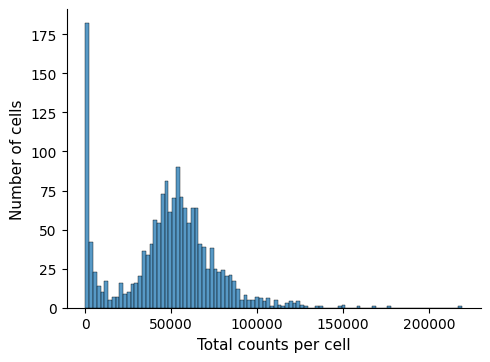

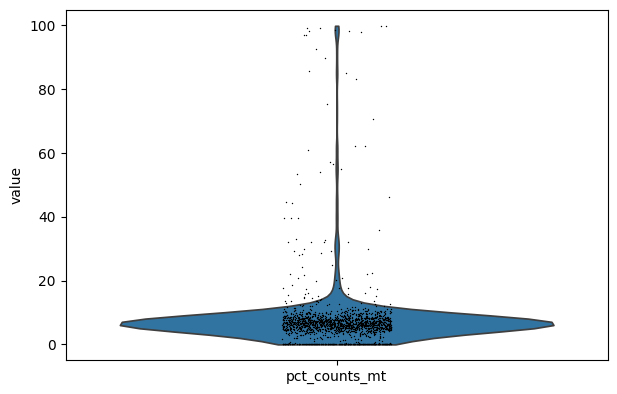

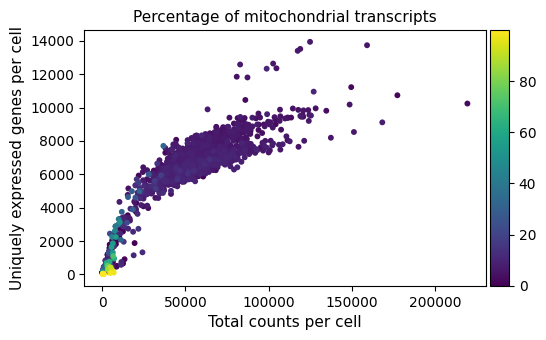

In [25]:
p1 = sns.displot(adata.obs["total_counts"], bins=100, kde=False)
p1.set_axis_labels("Total counts per cell", "Number of cells", fontsize=11)
p1.figure.set_size_inches(5, 3.5)
p2 = sc.pl.violin(adata, "pct_counts_mt")
p3 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt", show=False)
p3.set_xlabel("Total counts per cell", fontsize=11)
p3.set_ylabel("Uniquely expressed genes per cell", fontsize=11)
p3.set_title("Percentage of mitochondrial transcripts", fontsize=11)
p3.figure.set_size_inches(6, 3.5)

In [26]:
def is_outlier(adata, metric: str, nmads: int, batch_key: str = None):
    """
    Outlier detection based on MAD (global oder batch-aware).
    """
    values = adata.obs[metric]
    outlier_flags = pd.Series(False, index=adata.obs.index, dtype=bool)

    if batch_key is None:
        # global
        M = values
        med = np.median(M)
        mad = median_abs_deviation(M, scale=1)
        if mad > 0:
            outlier_flags[:] = (M < med - nmads * mad) | (M > med + nmads * mad)
    else:
        # batch-aware
        for batch, idx in adata.obs.groupby(batch_key).groups.items():
            M = values.loc[idx]   
            med = np.median(M)
            mad = median_abs_deviation(M, scale=1)
            if mad == 0:
                continue
            outliers = (M < med - nmads * mad) | (M > med + nmads * mad)
            outlier_flags.loc[idx] = outliers

    return outlier_flags

In [27]:
adata.obs["outlier"] = (
    is_outlier(adata, "log1p_total_counts", 5)
    | is_outlier(adata, "log1p_n_genes_by_counts", 5)
    | is_outlier(adata, "pct_counts_in_top_20_genes", 5)
)
adata.obs.outlier.value_counts()

outlier
False    1363
True      309
Name: count, dtype: int64

In [28]:
# threshold differs between datasets
high_quality = ["hgmm1k", "hgmm10k"]
if dataset in high_quality:
    threshold = 8
else:
    threshold = 20

adata.obs["mt_outlier"] = adata.obs["pct_counts_mt"] > threshold
adata.obs.mt_outlier.value_counts()

mt_outlier
False    1277
True      395
Name: count, dtype: int64

In [29]:
print(f"Total number of cells: {adata.n_obs}")
adata = adata[(~adata.obs.outlier) & (~adata.obs.mt_outlier)].copy()

print(f"Number of cells after filtering of low quality cells: {adata.n_obs}")

Total number of cells: 1672
Number of cells after filtering of low quality cells: 1060


### Classify human and mouse cells

In [30]:
if dataset != "hgmm10k":
    mouse_genome = "mm10"
else:
    mouse_genome = "GRCm39"

hg19 = ["hgmm5k", "hgmm6k", "hgmm12k"]
if dataset in hg19:
    human_genome = "hg19"
else:
    human_genome = "GRCh38"

adata.obs["human_counts_unc"] = adata[:, adata.var["genome"]==human_genome].layers["raw"].sum(axis=1)
adata.obs["mouse_counts_unc"] = adata[:, adata.var["genome"]==mouse_genome].layers["raw"].sum(axis=1)

In [31]:
adata.obs['human count ratio'] = adata.obs['human_counts_unc']/(adata.obs['mouse_counts_unc'] + adata.obs['human_counts_unc'])
adata.obs['mouse count ratio'] = adata.obs['mouse_counts_unc']/(adata.obs['mouse_counts_unc'] + adata.obs['human_counts_unc'])

In [32]:
import numpy as np

adata.obs['species_raw'] = np.where(
    adata.obs['human count ratio'] > adata.obs['mouse count ratio'],
    'human', 'mouse'
)

adata.obs["majority_ratio"] = np.maximum(
    adata.obs['human count ratio'], adata.obs['mouse count ratio']
)

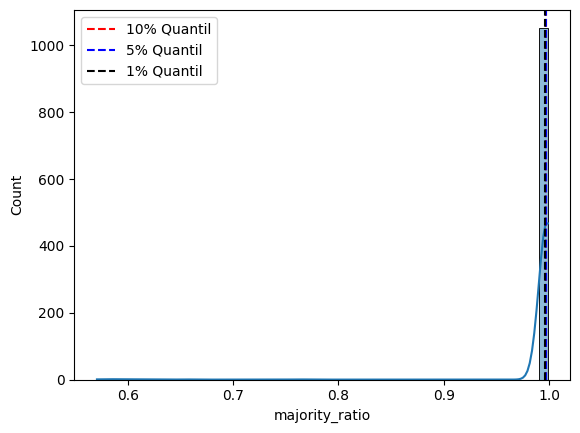

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

vals_human = adata.obs.loc[:, 'majority_ratio']
q90_h = np.percentile(vals_human, 10)
q95_h = np.percentile(vals_human, 5)
q99_h = np.percentile(vals_human, 1)

sns.histplot(vals_human, bins=50, kde=True)
plt.axvline(q90_h, color="red", linestyle="--", label="10% Quantil")
plt.axvline(q95_h, color="blue", linestyle="--", label="5% Quantil")
plt.axvline(q99_h, color="black", linestyle="--", label="1% Quantil")
plt.title("")
plt.legend()
plt.show()

In [34]:
# 5%-Quantil of majority_ratio-distribution
if dataset == "hgmm1k":
    quantile = 1
else:
    quantile = 5

global_thresh = np.percentile(adata.obs["majority_ratio"], quantile)

def refine_species_global(row, global_thresh):
    if row["majority_ratio"] > global_thresh:
        return row["species_raw"]   # stays Human or Mouse
    else:
        return "ambiguous"

adata.obs["species_refined"] = adata.obs.apply(
    refine_species_global, axis=1, args=(global_thresh,)
)


In [35]:
adata.obs['species_refined'].value_counts()

species_refined
human        564
mouse        485
ambiguous     11
Name: count, dtype: int64

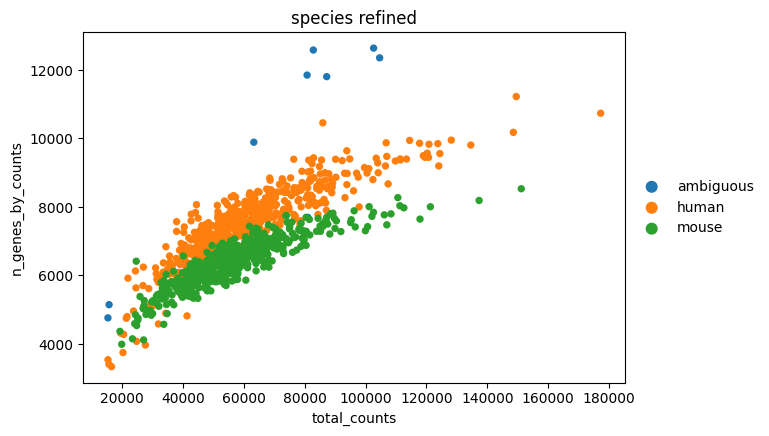

In [36]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="species_refined")

In [37]:
adata.obs["total_counts_unc"] = adata.obs["mouse_counts_unc"] + adata.obs["human_counts_unc"]

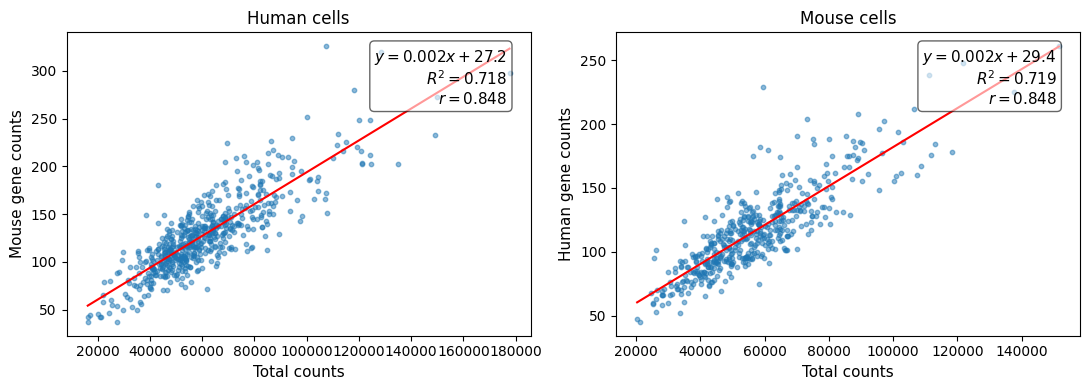

Human cells:
  Steigung (m): 0.0017
  Achsenabschnitt (b): 27.1622
  R² = 0.7183
  Pearson r = 0.8475 (p = 9.37e-157)

Mouse cells:
  Steigung (m): 0.0015
  Achsenabschnitt (b): 29.4001
  R² = 0.7187
  Pearson r = 0.8477 (p = 4.18e-135)


In [38]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score
from scipy.stats import pearsonr

# --- Human cells ---
human_cells = adata[adata.obs["species_refined"] == "human"]
x_h = human_cells.obs["total_counts_unc"]
y_h = human_cells.obs["mouse_counts_unc"]

m_h, b_h = np.polyfit(x_h, y_h, 1)
y_pred_h = m_h * x_h + b_h
r2_h = r2_score(y_h, y_pred_h)
r_h, p_h = pearsonr(x_h, y_h)

# --- Mouse cells ---
mouse_cells = adata[adata.obs["species_refined"] == "mouse"]
x_m = mouse_cells.obs["total_counts_unc"]
y_m = mouse_cells.obs["human_counts_unc"]

m_m, b_m = np.polyfit(x_m, y_m, 1)
y_pred_m = m_m * x_m + b_m
r2_m = r2_score(y_m, y_pred_m)
r_m, p_m = pearsonr(x_m, y_m)

# --- Figure-Layout ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# --- Plot 1: Human cells ---
axes[0].scatter(x_h, y_h, alpha=0.5, s=10)
axes[0].plot(np.unique(x_h), np.poly1d((m_h, b_h))(np.unique(x_h)), color='red')
axes[0].set_xlabel("Total counts", fontsize=11)
axes[0].set_ylabel("Mouse gene counts", fontsize=11)
axes[0].set_title("Human cells")
axes[0].text(
    0.95, 0.95,
    f"$y = {m_h:.3f} x + {b_h:.1f}$\n$R^2 = {r2_h:.3f}$\n$r = {r_h:.3f}$",
    transform=axes[0].transAxes,
    fontsize=11,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.6)
)

# --- Plot 2: Mouse cells ---
axes[1].scatter(x_m, y_m, alpha=0.5, s=10)
axes[1].plot(np.unique(x_m), np.poly1d((m_m, b_m))(np.unique(x_m)), color='red')
axes[1].set_xlabel("Total counts", fontsize=11)
axes[1].set_ylabel("Human gene counts", fontsize=11)
axes[1].set_title("Mouse cells")
axes[1].text(
    0.95, 0.95,
    f"$y = {m_m:.3f} x + {b_m:.1f}$\n$R^2 = {r2_m:.3f}$\n$r = {r_m:.3f}$",
    transform=axes[1].transAxes,
    fontsize=11,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.6)
)

plt.tight_layout()
plt.show()

# --- Results in Terminal ---
print("Human cells:")
print(f"  Steigung (m): {m_h:.4f}")
print(f"  Achsenabschnitt (b): {b_h:.4f}")
print(f"  R² = {r2_h:.4f}")
print(f"  Pearson r = {r_h:.4f} (p = {p_h:.2e})\n")

print("Mouse cells:")
print(f"  Steigung (m): {m_m:.4f}")
print(f"  Achsenabschnitt (b): {b_m:.4f}")
print(f"  R² = {r2_m:.4f}")
print(f"  Pearson r = {r_m:.4f} (p = {p_m:.2e})")


### Ambient RNA correction

In [ ]:
# ambient RNA was already corrected

In [39]:
# use float32 for compatibility with scrublet
adata.X = adata.X.astype(np.float32)
for layer in adata.layers:
    adata.layers[layer] = adata.layers[layer].astype(np.float32)

### Doublet detection

In [40]:
# doublet detection with scrublet
sc.pp.scrublet(adata)

/home/luschroe/miniconda3/envs/benchmarking/lib/python3.11/site-packages/scanpy/preprocessing/_scrublet/core.py:323: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  AnnData(
/home/luschroe/miniconda3/envs/benchmarking/lib/python3.11/site-packages/scanpy/preprocessing/_scrublet/core.py:323: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  AnnData(


### Normalization

In [41]:
scales_counts = sc.pp.normalize_total(adata, target_sum=None, inplace=False)
# log1p transform
adata.layers["log1p_norm"] = sc.pp.log1p(scales_counts["X"], copy=True)

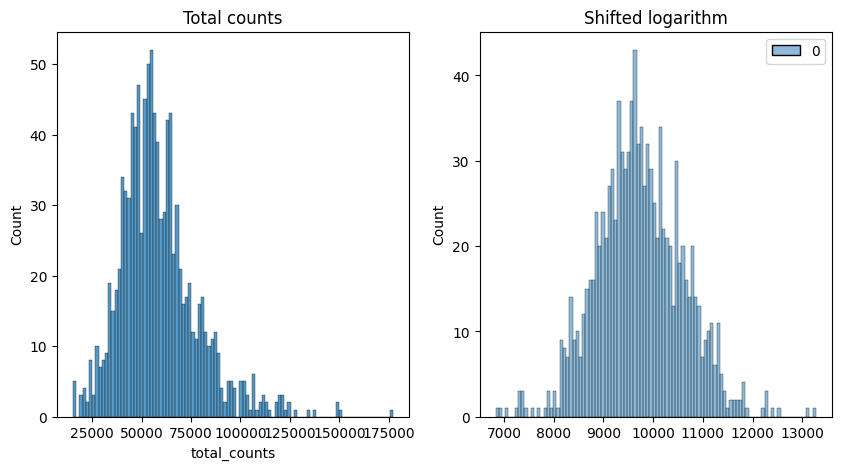

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts")
p2 = sns.histplot(adata.layers["log1p_norm"].sum(1), bins=100, kde=False, ax=axes[1])
axes[1].set_title("Shifted logarithm")
plt.show()

### Feature selection

In [43]:
# pca was calculated on all genes!
sc.pp.highly_variable_genes(adata, flavor='seurat_v3', n_top_genes=2000)

### Dimensionality reduction

In [44]:
adata.X = adata.layers["log1p_norm"]

In [45]:
# scaling can improve PCA
sc.pp.scale(adata, max_value=10)

/home/luschroe/miniconda3/envs/benchmarking/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [46]:
# use all genes not only hvgs
sc.pp.pca(adata, svd_solver="arpack", use_highly_variable=False)

/home/luschroe/miniconda3/envs/benchmarking/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


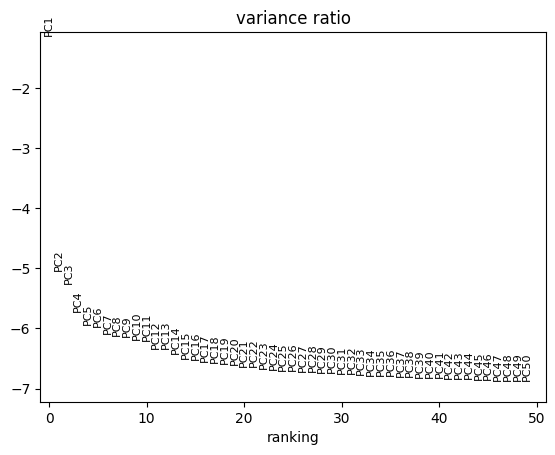

In [47]:
# compute variance ratio across Principal Component
sc.pl.pca_variance_ratio(adata, log=True, n_pcs=50)

In [48]:
# compute tsne
sc.tl.tsne(adata, use_rep="X_pca")

In [49]:
# compute neighbors and umap
sc.pp.neighbors(adata)
sc.tl.umap(adata, random_state=42)

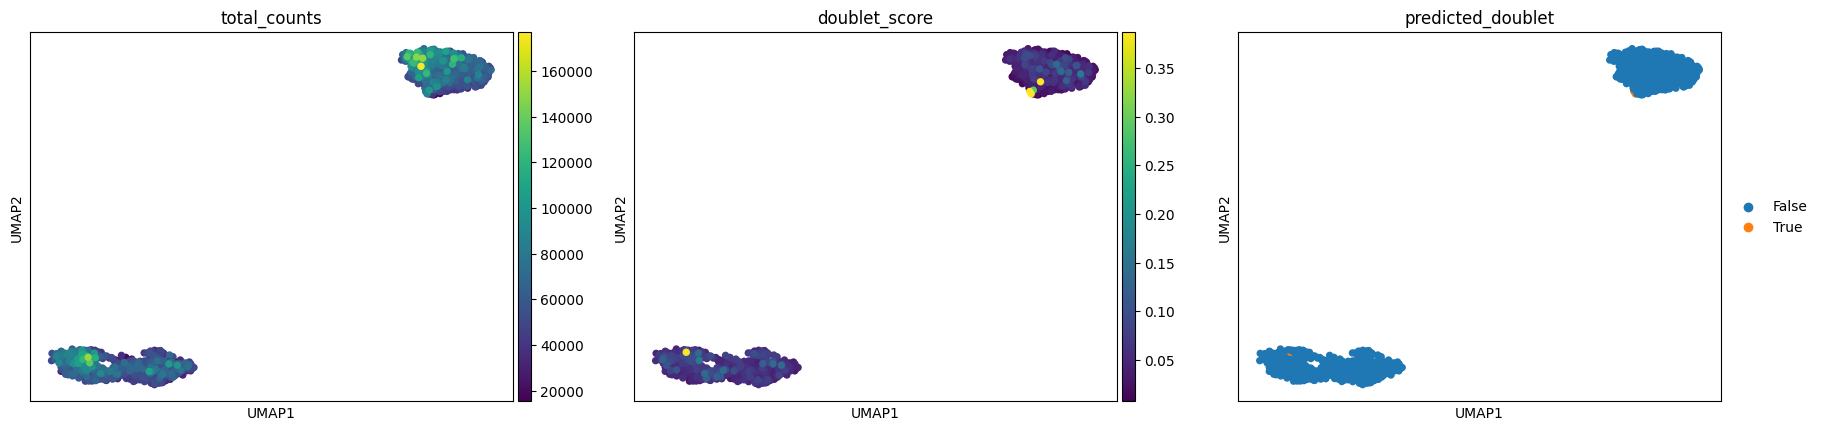

In [50]:
# inspecting quality control metrics
sc.pl.umap(
    adata,
    color=["total_counts", "doublet_score", "predicted_doublet"],
)

### Clustering

In [51]:
sc.tl.leiden(adata, key_added="leiden_res0_25", resolution=0.25)
sc.tl.leiden(adata, key_added="leiden_res0_5", resolution=0.5)
sc.tl.leiden(adata, key_added="leiden_res1", resolution=1.0)

/tmp/ipykernel_83198/3088376165.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, key_added="leiden_res0_25", resolution=0.25)


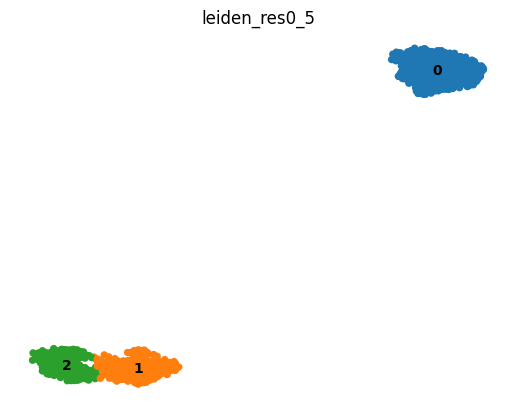

In [52]:
sc.pl.umap(
    adata,
    color= "leiden_res0_5",
    legend_loc="on data",
    frameon=False
)

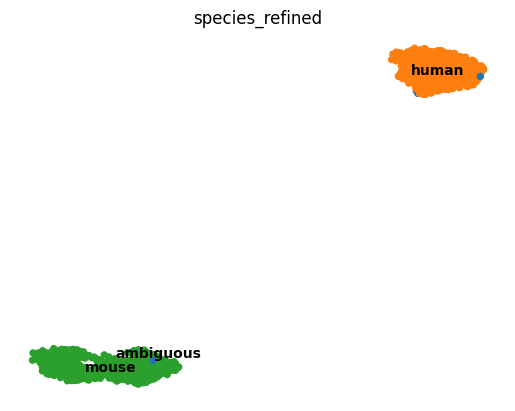

In [53]:
sc.pl.umap(
    adata,
    color= "species_refined",
    legend_loc="on data",
    frameon=False
)

In [ ]:
sc.write(f"{PATH}/{dataset}_cellbender_processed.h5ad", adata)